In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import requests
from io import StringIO

API = "https://en.wikipedia.org/w/api.php"
params = {
    "action": "parse",
    "page": "List_of_S&P_500_companies",
    "prop": "text",
    "format": "json"
}
headers = {"User-Agent": "sp500_ticker_tutorial/1.0"}

r = requests.get(API, params=params, headers=headers)
html = r.json()["parse"]["text"]["*"]
df_wiki = pd.read_html(StringIO(html))[0]

tickers = df_wiki["Symbol"].astype(str).tolist()
tickers = [t.replace(".", "-") for t in tickers]

print("Tickers ready:", len(tickers))

Tickers ready: 503


In [3]:
data = yf.download(tickers, start="2015-01-01", auto_adjust=True)["Close"]
monthly = data.resample("ME").last()
print(monthly.shape)

[*********************100%***********************]  503 of 503 completed


(139, 503)


In [4]:
monthly_returns = monthly.pct_change()
momentum_12 = (1 + monthly_returns).rolling(12).apply(np.prod) - 1
momentum_12.dropna(how="all", inplace=True)
print(momentum_12.shape)

(127, 503)


In [5]:
ranked_12 = momentum_12.rank(axis=1, ascending=True)
ranked_12.dropna(how="all", inplace=True)
print(ranked_12.shape)

(127, 503)


In [6]:
buy_signal_90 = ranked_12.gt(ranked_12.quantile(0.90, axis=1), axis=0)
print("Stocks bought in first month (90th pct):", buy_signal_90.iloc[0].sum())

buy_signal = ranked_12.gt(ranked_12.quantile(0.98, axis=1), axis=0)
print("Stocks bought in first month (98th pct):", buy_signal.iloc[0].sum())

Stocks bought in first month (90th pct): 46
Stocks bought in first month (98th pct): 10


In [7]:
next_month_return = monthly_returns.shift(-1)
strategy_return = next_month_return[buy_signal].mean(axis=1).dropna()
cumulative_return = (1 + strategy_return).cumprod() - 1

print("Final Cumulative Return:", cumulative_return.iloc[-1])
print("Total Return %:", round((cumulative_return.iloc[-1]) * 100, 2), "%")

Final Cumulative Return: 109.94374591270727
Total Return %: 10994.37 %


In [8]:
for n in [10, 20, 46]:
    top_n = ranked_12.gt(ranked_12.quantile(1 - n/503, axis=1), axis=0)
    strat_ret = next_month_return[top_n].mean(axis=1).dropna()
    cumul = (1 + strat_ret).cumprod().iloc[-1]
    print("Top", n, "stocks →", round((cumul-1)*100, 2), "% return")

Top 10 stocks → 10994.37 % return
Top 20 stocks → 3291.02 % return
Top 46 stocks → 1390.73 % return


In [9]:
def stocks_bought(month_date):
    row = buy_signal.loc[month_date]
    return row[row].index.tolist()

print(buy_signal.index[-1].date())
print(buy_signal.iloc[-1][buy_signal.iloc[-1]].index.tolist())

2026-07-31
['CIEN', 'DELL', 'INTC', 'LITE', 'LRCX', 'MU', 'SNDK', 'STX', 'TER', 'WDC']


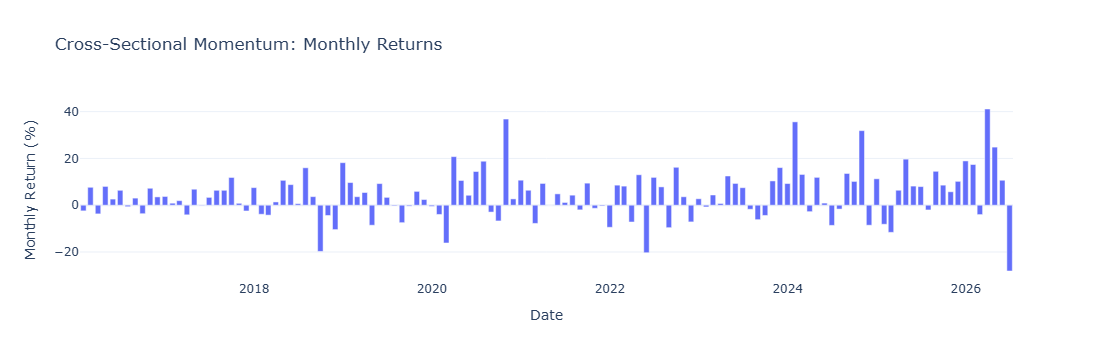

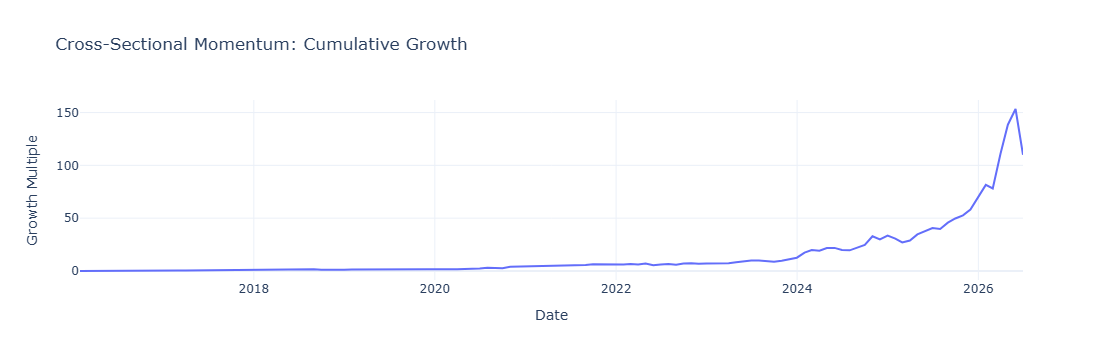

In [10]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Bar(
    x=strategy_return.index,
    y=strategy_return.values * 100,
    name="Monthly Strategy Return (%)"
))
fig.update_layout(
    title="Cross-Sectional Momentum: Monthly Returns",
    xaxis_title="Date",
    yaxis_title="Monthly Return (%)",
    template="plotly_white"
)
fig.show()

fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=cumulative_return.index,
    y=cumulative_return.values,
    mode="lines",
    name="Cross-Sectional Momentum"
))
fig2.update_layout(
    title="Cross-Sectional Momentum: Cumulative Growth",
    xaxis_title="Date",
    yaxis_title="Growth Multiple",
    template="plotly_white"
)
fig2.show()

In [13]:
target_month = pd.Timestamp("2026-05-31")

holdings_mask = ranked_12.gt(ranked_12.quantile(0.98, axis=1), axis=0).loc[target_month]
held_tickers = holdings_mask[holdings_mask].index.tolist()

actual_returns = monthly_returns.loc["2026-06-30", held_tickers]

print("Stocks held (ranked as of", target_month.date(), "), sorted by realized return:")
print(actual_returns.sort_values())
print("Manual average:", actual_returns.mean())

Stocks held (ranked as of 2026-05-31 ), sorted by realized return:
Ticker
ECHO   -0.214335
CIEN   -0.154542
LITE    0.003626
COHR    0.091294
STX     0.097622
MU      0.188764
WDC     0.202700
INTC    0.217562
TER     0.292618
SNDK    0.341449
Name: 2026-06-30 00:00:00, dtype: float64
Manual average: 0.10667588889945676


In [14]:
current_holdings_month = pd.Timestamp("2026-06-30")

current_holdings = ranked_12.gt(ranked_12.quantile(0.98, axis=1), axis=0).loc[current_holdings_month]
current_tickers = current_holdings[current_holdings].index.tolist()

print("Current holdings (ranked as of June 30):")
print(current_tickers)

Current holdings (ranked as of June 30):
['CIEN', 'GLW', 'INTC', 'LITE', 'LRCX', 'MU', 'SNDK', 'STX', 'TER', 'WDC']


In [15]:
current_90pct_mask = ranked_12.gt(ranked_12.quantile(0.90, axis=1), axis=0).loc[pd.Timestamp("2026-06-30")]
current_90pct = current_90pct_mask[current_90pct_mask].index.tolist()

print("Number of stocks:", len(current_90pct))
print(current_90pct)

Number of stocks: 50
['ALB', 'AMAT', 'AMD', 'APA', 'APH', 'BIIB', 'CAT', 'CHRW', 'CIEN', 'CMI', 'COHR', 'CSCO', 'DAL', 'DDOG', 'DELL', 'ECHO', 'FDX', 'FIX', 'FLEX', 'GEV', 'GLW', 'GNRC', 'GOOG', 'GOOGL', 'HPE', 'INTC', 'IVZ', 'JBHT', 'JBL', 'KEYS', 'KLAC', 'LITE', 'LRCX', 'MPWR', 'MRNA', 'MRVL', 'MU', 'NUE', 'ON', 'PWR', 'SNDK', 'STLD', 'STX', 'TER', 'UAL', 'VLO', 'VRT', 'VTRS', 'WBD', 'WDC']


In [16]:
current_holdings_month = pd.Timestamp("2026-06-30")

current_holdings = ranked_12.gt(ranked_12.quantile(0.98, axis=1), axis=0).loc[current_holdings_month]
current_tickers = current_holdings[current_holdings].index.tolist()

print("Current holdings (ranked as of June 30):")
print(current_tickers)

current_returns_so_far = monthly_returns.loc["2026-07-31", current_tickers] if "2026-07-31" in monthly_returns.index else "July not yet in monthly data"
print(current_returns_so_far)

Current holdings (ranked as of June 30):
['CIEN', 'GLW', 'INTC', 'LITE', 'LRCX', 'MU', 'SNDK', 'STX', 'TER', 'WDC']
Ticker
CIEN   -0.236770
GLW    -0.394707
INTC   -0.319344
LITE   -0.145957
LRCX   -0.276994
MU     -0.264413
SNDK   -0.404142
STX    -0.183772
TER    -0.333747
WDC    -0.252849
Name: 2026-07-31 00:00:00, dtype: float64


In [17]:
live_prices = yf.download(current_tickers, period="1mo")["Close"]

month_start_price = live_prices.iloc[0]
latest_price = live_prices.iloc[-1]

pct_change_so_far = (latest_price / month_start_price - 1)

print("Performance since start of month, sorted worst to best:")
print(pct_change_so_far.sort_values())

[*********************100%***********************]  10 of 10 completed


Performance since start of month, sorted worst to best:
Ticker
SNDK   -0.379874
WDC    -0.360492
INTC   -0.290693
TER    -0.263884
STX    -0.263503
MU     -0.251245
GLW    -0.206803
LRCX   -0.194684
LITE   -0.137859
CIEN   -0.125660
dtype: float64


In [1]:
import os
print(os.getcwd())

C:\Users\fanad
